<a href="https://colab.research.google.com/github/esemsc-db24/NewRytm/blob/main/Neuro_science_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier

In [2]:
## importing drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
training_data = pd.read_csv("/content/drive/MyDrive/NEUROSCIENCE/DATASETS/train.csv")
test_data = pd.read_csv("/content/drive/MyDrive/NEUROSCIENCE/DATASETS/test.csv")

The dataset used is the following: https://www.kaggle.com/datasets/qiriro/swell-heart-rate-variability-hrv/data


In [4]:
training_data.head()

,MEAN_RR,MEDIAN_RR,SDRR,RMSSD,SDSD,SDRR_RMSSD,HR,pNN25,pNN50,SD1,...,HF,HF_PCT,HF_NU,TP,LF_HF,HF_LF,sampen,higuci,datasetId,condition
0,885.157845,853.763730,140.972741,15.554505,15.553371,9.063146,69.499952,11.133333,0.533333,11.001565,...,15.522603,0.421047,1.514737,3686.666157,65.018055,0.015380,2.139754,1.163485,2,no stress
1,939.425371,948.357865,81.317742,12.964439,12.964195,6.272369,64.363150,5.600000,0.000000,9.170129,...,2.108525,0.070133,0.304603,3006.487251,327.296635,0.003055,2.174499,1.084711,2,interruption
2,898.186047,907.006860,84.497236,16.305279,16.305274,5.182201,67.450066,13.066667,0.200000,11.533417,...,13.769729,0.512671,1.049528,2685.879461,94.280910,0.010607,2.135350,1.176315,2,interruption
3,881.757865,893.460030,90.370537,15.720468,15.720068,5.748591,68.809562,11.800000,0.133333,11.119476,...,18.181913,0.529387,1.775294,3434.520980,55.328701,0.018074,2.178341,1.179688,2,no stress
4,809.625331,811.184865,62.766242,19.213819,19.213657,3.266724,74.565728,20.200000,0.200000,13.590641,...,48.215822,1.839473,3.279993,2621.175204,29.487873,0.033912,2.221121,1.249612,2,no stress


In [5]:
test_data.head()

,MEAN_RR,MEDIAN_RR,SDRR,RMSSD,SDSD,SDRR_RMSSD,HR,pNN25,pNN50,SD1,...,HF,HF_PCT,HF_NU,TP,LF_HF,HF_LF,sampen,higuci,datasetId,condition
0,721.901897,727.267280,74.722315,12.361264,12.361069,6.044877,84.121868,4.933333,0.000000,8.743513,...,66.617057,3.921868,9.760289,1698.605390,9.245599,0.108160,2.097342,1.243696,2,no stress
1,843.538633,844.407930,58.499429,19.298880,19.298795,3.031234,71.478642,21.000000,0.200000,13.650863,...,26.500086,1.123416,1.663151,2358.884694,59.126832,0.016913,2.217275,1.250056,2,time pressure
2,958.523868,966.671125,132.849110,21.342715,21.342653,6.224565,63.874293,24.133333,1.800000,15.096571,...,16.024935,0.370208,0.766416,4328.633724,129.477524,0.007723,2.217136,1.144943,2,no stress
3,824.838669,842.485905,117.822094,11.771814,11.771248,10.008830,74.330531,4.733333,0.533333,8.326307,...,17.581470,0.615932,3.358652,2854.449091,28.773854,0.034754,2.106863,1.142355,2,no stress
4,756.707933,747.941620,143.968457,13.357748,13.356388,10.777899,82.092049,5.933333,0.666667,9.447545,...,35.199054,0.662879,6.292253,5310.027472,14.892559,0.067148,1.912191,1.128098,2,interruption


MEAN_RR: The average time interval between consecutive R-wave peaks (heartbeats) over a recording period.

MEDIAN_RR: The median value of the R-R intervals, providing a central tendency less affected by outliers.

SDRR (Standard Deviation of R-R intervals): Reflects the overall variability in heartbeats; higher values indicate greater variability.

RMSSD (Root Mean Square of Successive Differences): Measures short-term variations by calculating the square root of the mean squared differences between successive R-R intervals; often associated with parasympathetic activity.

SDSD (Standard Deviation of Successive Differences): Assesses the variability between consecutive R-R intervals, similar to RMSSD.

SDRR_RMSSD: The ratio of SDRR to RMSSD, providing insight into the balance between overall variability and short-term fluctuations.

HR (Heart Rate): The number of heartbeats per minute.

pNN25: The percentage of consecutive R-R intervals that differ by more than 25 milliseconds; indicates parasympathetic activity.

pNN50: The percentage of consecutive R-R intervals that differ by more than 50 milliseconds; another indicator of parasympathetic activity.

SD1 and SD2: Parameters derived from Poincaré plots of R-R intervals; SD1 reflects short-term variability, while SD2 represents long-term variability.

KURT (Kurtosis): Measures the "tailedness" of the R-R interval distribution; higher values indicate more outliers.

SKEW (Skewness): Assesses the asymmetry of the R-R interval distribution; indicates whether the data are skewed to the left or right.

MEAN_REL_RR: Mean relative R-R interval.

MEDIAN_REL_RR: Median relative R-R interval.

SDRR_REL_RR: Standard deviation of relative R-R intervals.

RMSSD_REL_RR: RMSSD of relative R-R intervals.

SDSD_REL_RR: SDSD of relative R-R intervals.

SDRR_RMSSD_REL_RR: Ratio of SDRR to RMSSD for relative R-R intervals.

KURT_REL_RR: Kurtosis of relative R-R intervals.

SKEW_REL_RR: Skewness of relative R-R intervals.

VLF (Very Low Frequency): Power in the very low-frequency range (typically <0.04 Hz); associated with thermoregulation and other long-term regulatory mechanisms.

VLF_PCT: Percentage of total power in the VLF range.

LF (Low Frequency): Power in the low-frequency range (0.04–0.15 Hz); reflects a mix of sympathetic and parasympathetic activity.

LF_PCT: Percentage of total power in the LF range.

LF_NU (Normalized Units): LF power expressed in normalized units, emphasizing the relative value of LF power in proportion to the total power minus the VLF component.

HF (High Frequency): Power in the high-frequency range (0.15–0.4 Hz); associated with parasympathetic (vagal) activity and respiratory sinus arrhythmia.

HF_PCT: Percentage of total power in the HF range.

HF_NU (Normalized Units): HF power expressed in normalized units, highlighting the relative value of HF power in proportion to the total power minus the VLF component.

TP (Total Power): Overall variance in the R-R intervals over the recording period; represents total HRV.

LF_HF: Ratio of LF to HF power; used as an index of sympathovagal balance.

HF_LF: Ratio of HF to LF power; inverse of LF_HF.







In [6]:
training_data = training_data.drop_duplicates()
test_data = test_data.drop_duplicates()

training_data = training_data.drop(columns = "datasetId")
test_data = test_data.drop(columns = "datasetId")

training_data = training_data.dropna()
test_data = test_data.dropna()

y = training_data["condition"]
X = training_data.drop(columns= "condition")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)



In [7]:
X_train.columns

Index(['MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD', 'HR',
       'pNN25', 'pNN50', 'SD1', 'SD2', 'KURT', 'SKEW', 'MEAN_REL_RR',
       'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR',
       'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'VLF', 'VLF_PCT',
       'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF',
       'HF_LF', 'sampen', 'higuci'],
      dtype='object')

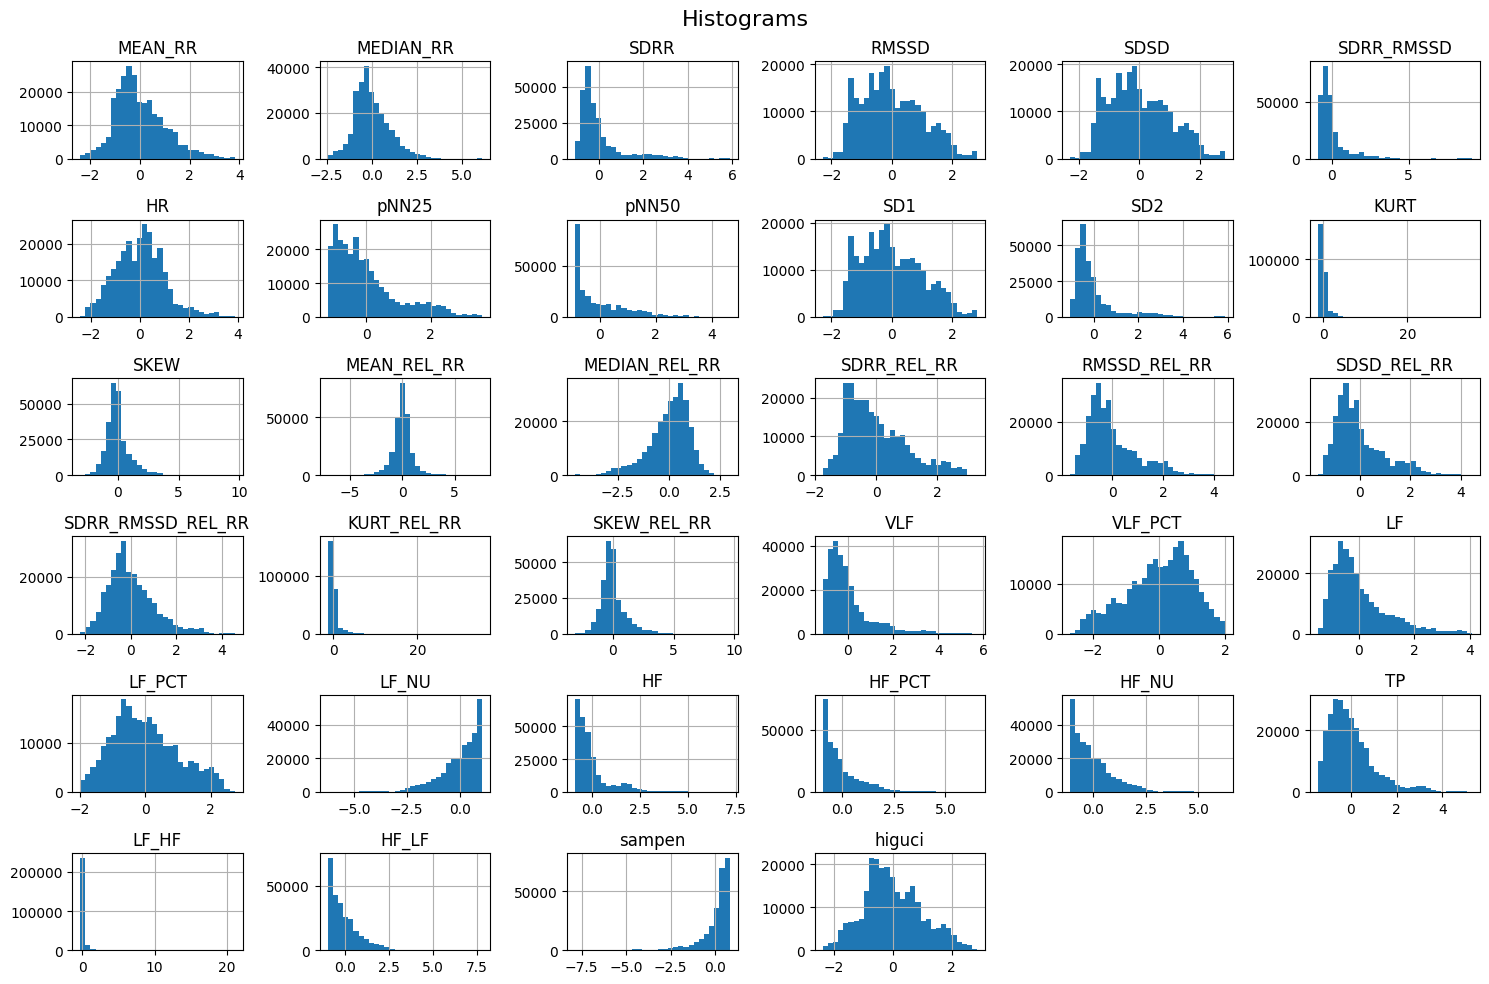

Index(['MEAN_RR', 'MEDIAN_RR', 'SDRR', 'RMSSD', 'SDSD', 'SDRR_RMSSD', 'HR',
       'pNN25', 'pNN50', 'SD1', 'SD2', 'KURT', 'SKEW', 'MEAN_REL_RR',
       'MEDIAN_REL_RR', 'SDRR_REL_RR', 'RMSSD_REL_RR', 'SDSD_REL_RR',
       'SDRR_RMSSD_REL_RR', 'KURT_REL_RR', 'SKEW_REL_RR', 'VLF', 'VLF_PCT',
       'LF', 'LF_PCT', 'LF_NU', 'HF', 'HF_PCT', 'HF_NU', 'TP', 'LF_HF',
       'HF_LF', 'sampen', 'higuci'],
      dtype='object')

In [8]:
#EDA
# there are some columns that need to be normalized - for now I will scale all of them so they contribute the same to the model
# A second step would be to understand the distribution of each column alone and and do a pipeline

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Need to retrasnform X_train in a dataframe

X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

X_train.hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms', fontsize=16)
plt.tight_layout()
plt.show()

X_train.columns


<Axes: >

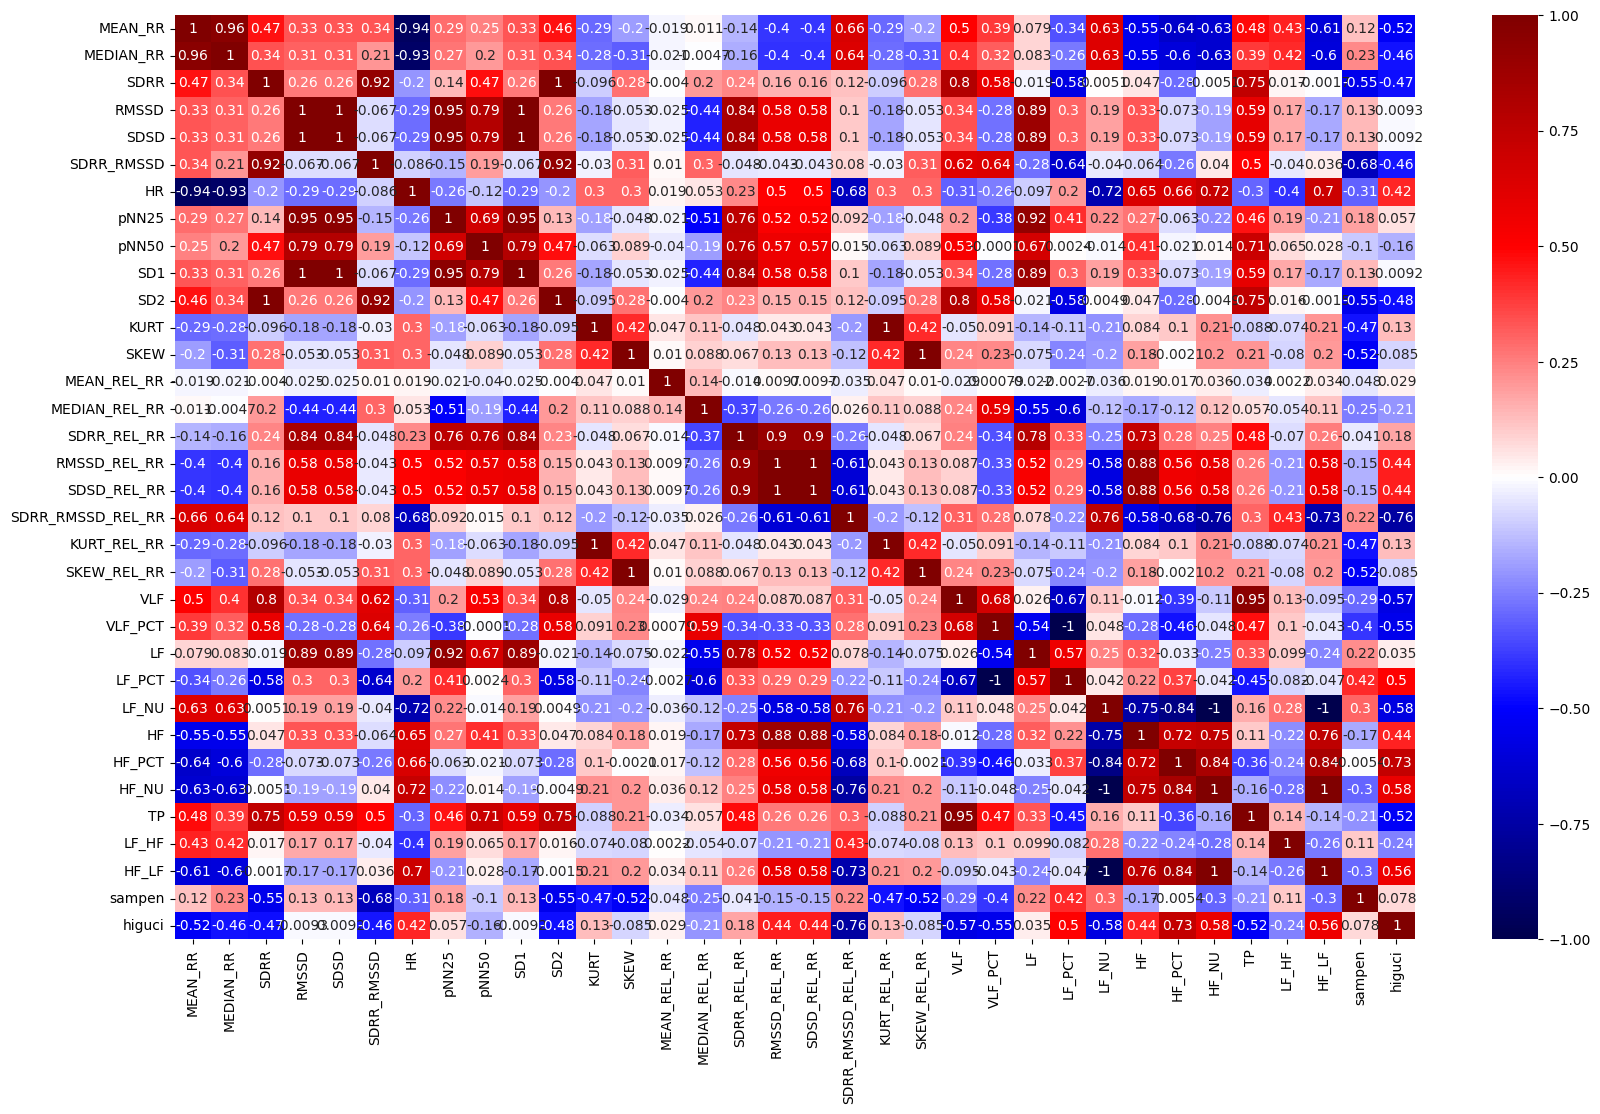

In [9]:
# This the correlation between different features- for now I will keep everything
corr = X_train.corr()
plt.figure(figsize=(20, 12))
sns.heatmap(corr,
        xticklabels=corr.columns,
        yticklabels=corr.columns,
        cmap= "seismic", annot=True)


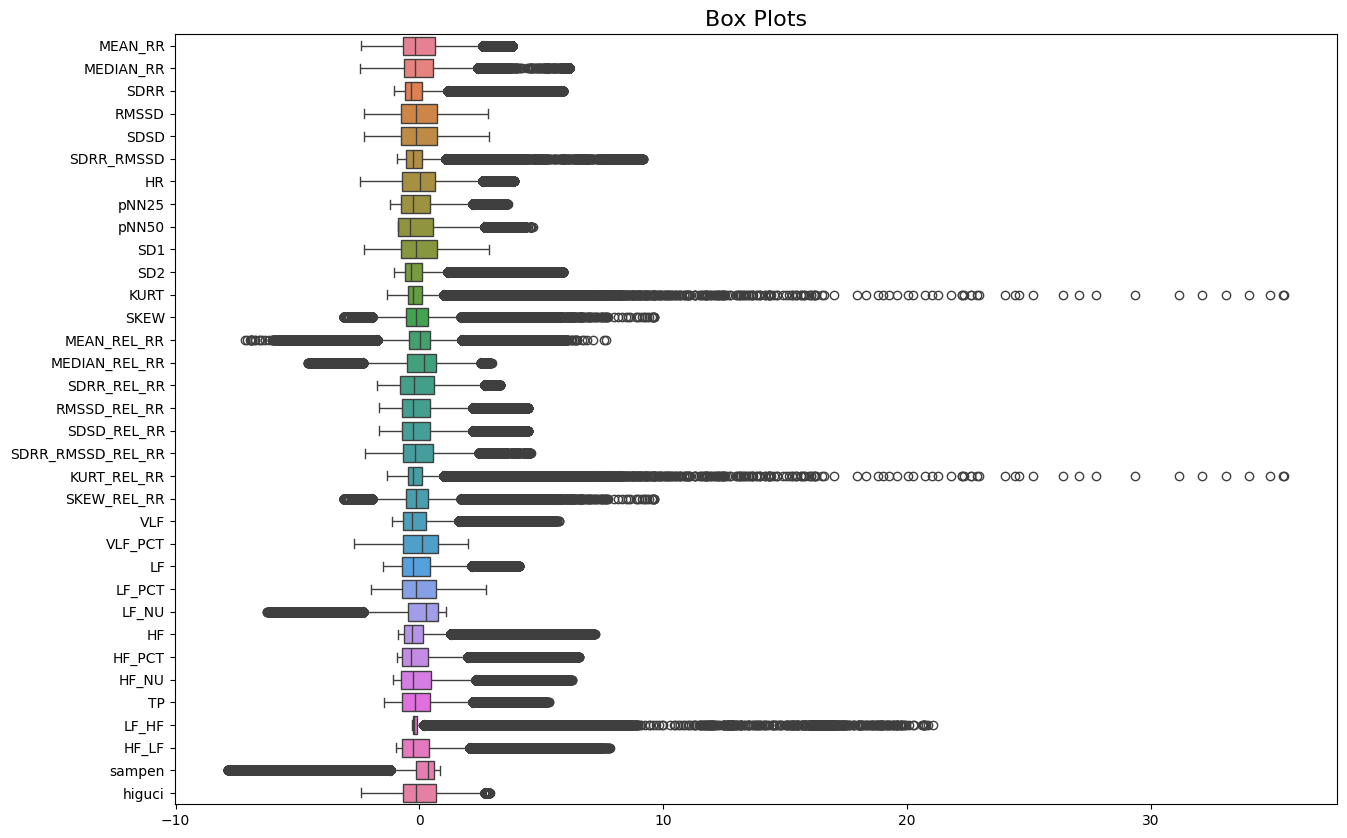

In [10]:
# Boxplotting to understand outliers
# for now I am keeping all the outliers but lets permutate some features and let's see

plt.figure(figsize=(15, 10))
sns.boxplot(data=X_train, orient='h')
plt.title('Box Plots', fontsize=16)
plt.show()


In [11]:
model1 = LinearRegression() # reference_3

model1.fit(X_train, y_train)

permutation_score = permutation_importance(model1, X_train, y_train, n_repeats=10)

importance_df = pd.DataFrame(np.vstack((X_train.columns,
                                        permutation_score.importances_mean)).T) # Unstack results
importance_df.columns=['feature','score decrease']

importance_df.sort_values(by="score decrease", ascending = False) # Order by importance

,feature,score decrease
16,RMSSD_REL_RR,1994765.205014
17,SDSD_REL_RR,1994223.07227
2,SDRR,44155.176639
10,SD2,43777.727033
3,RMSSD,2118.866185
9,SD1,554.408151
4,SDSD,554.40815
31,HF_LF,1.827505
23,LF,0.996648
0,MEAN_RR,0.595508


In [12]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)



In [13]:
# MODELS
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Logistic regression with multiple classes
logreg = LogisticRegression(max_iter=5000, random_state=42)
ovr_classifier = OneVsRestClassifier(logreg)
ovr_classifier.fit(X_train_pca, y_train)
y_pred_ovr = ovr_classifier.predict(X_test_pca)

# Knn
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pca, y_train)
y_pred_knn = knn.predict(X_test_pca)

# Decision trees
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train_pca, y_train)
y_pred_tree = tree.predict(X_test_pca)


In [14]:
#OVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred_ovr)
precision = precision_score(y_test, y_pred_ovr, average = "weighted")
recall = recall_score(y_test, y_pred_ovr, average="weighted")
f1 = f1_score(y_test, y_pred_ovr, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred_ovr)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.5986081399442172
Precision: 0.5815828908409321
Recall: 0.5986081399442172
F1 Score: 0.5564702774480956
Confusion Matrix:
[[ 9070 19964  2517]
 [ 6571 52673   783]
 [ 2060 12574  4575]]


In [15]:
# knn
accuracy = accuracy_score(y_test, y_pred_knn)
precision = precision_score(y_test, y_pred_knn, average = "weighted")
recall = recall_score(y_test, y_pred_knn, average="weighted")
f1 = f1_score(y_test, y_pred_knn, average="weighted")
conf_matrix = confusion_matrix(y_test, y_pred_knn)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)


Accuracy: 0.9999729210105879
Precision: 0.9999729216849376
Recall: 0.9999729210105879
F1 Score: 0.9999729209066376
Confusion Matrix:
[[31551     0     0]
 [    0 60026     1]
 [    2     0 19207]]


In [17]:
# Decision trees
accuracy = accuracy_score(y_test, y_pred_tree)
precision = precision_score(y_test, y_pred_tree, average = "weighted")
recall = recall_score(y_test, y_pred_tree, average="weighted")
f1 = f1_score(y_test, y_pred_tree, average="weighted")
conf_matrix = confusion_matrix(y_test,y_pred_tree)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1 Score: {f1}")
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.9972379430799643
Precision: 0.9972378032635619
Recall: 0.9972379430799643
F1 Score: 0.9972378407796112
Confusion Matrix:
[[31450    82    19]
 [   75 59904    48]
 [   29    53 19127]]
